<center>

# **PyTorch: Tutorial**

</center>


---

**Autor**: Isaac Yael Cantú Fernández

**Fecha**: 04/2026

In [5]:
import torch   
import numpy as np

In [3]:
py_list = [1,2,3,4,5]
py_list

[1, 2, 3, 4, 5]

In [6]:
np_list = np.array([1,2,3,4,5])
np_list

array([1, 2, 3, 4, 5])

In [8]:
pt_list = torch.tensor([1,2,3,4,5])
pt_list

tensor([1, 2, 3, 4, 5])

In [9]:
# numpy -> tensor
my_tensor = torch.tensor(np_list)
my_tensor

tensor([1, 2, 3, 4, 5])

In [15]:
my_tensor = torch.arange(100)
my_tensor

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [22]:
my_tensor = my_tensor.reshape(10,10)
my_tensor

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
        [60, 61, 62, 63, 64, 65, 66, 67, 68, 69],
        [70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
        [80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
        [90, 91, 92, 93, 94, 95, 96, 97, 98, 99]])

In [28]:
my_tensor = torch.arange(100)
my_tensor = my_tensor.view(10,10)
my_tensor

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
        [60, 61, 62, 63, 64, 65, 66, 67, 68, 69],
        [70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
        [80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
        [90, 91, 92, 93, 94, 95, 96, 97, 98, 99]])

## **Neural Network**

In [31]:
import torch
import torch.nn as nn 
import torch.nn.functional as F

In [36]:
# nn.Module

class Model(nn.Module):

    def __init__(self, in_feature=4, h1=8, h2=9, out_feature=3):
        super().__init__()
        self.fc1 = nn.Linear(in_feature, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_feature)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x
    


In [37]:
torch.manual_seed(41) #seed

model = Model()

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [47]:
flowers = list(set(df.species))
df.species = df.species.replace(flowers[0],0)
df.species = df.species.replace(flowers[1],1)
df.species = df.species.replace(flowers[2],2)

In [59]:
df.species.value_counts()

species
0    50
2    50
1    50
Name: count, dtype: int64

In [64]:
X = df.drop("species",axis=1)
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [65]:
Y = df.species
Y

0      0
1      0
2      0
3      0
4      0
      ..
145    1
146    1
147    1
148    1
149    1
Name: species, Length: 150, dtype: object

In [67]:
X = X.values
Y = Y.values

In [68]:
from sklearn.model_selection import train_test_split

In [83]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y.astype("int64"), train_size=0.8, random_state=41)

In [84]:
ytrain

array([2, 2, 1, 2, 1, 0, 1, 2, 1, 2, 2, 2, 0, 1, 1, 0, 1, 2, 0, 2, 1, 2,
       1, 0, 0, 1, 1, 0, 2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 1, 0, 2, 2, 0, 1,
       2, 0, 1, 1, 0, 2, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 0,
       0, 1, 1, 1, 2, 2, 1, 0, 2, 1, 2, 2, 0, 2, 0, 2, 0, 2, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 2, 1, 2, 0, 1, 0, 2, 0, 1, 2, 2,
       1, 2, 2, 1, 1, 0, 2, 2, 2, 1])

In [ ]:
Xtrain = torch.FloatTensor(Xtrain)
Xtest = torch.FloatTensor(Xtest)
ytrain = torch.LongTeinsor(ytrain)
ytest = torch.LongTensor(ytest)

In [86]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [93]:
epochs = 200
losses = []
for i in range(epochs):
    y_pred = model.forward(Xtrain)

    loss = criterion(y_pred, ytrain)

    losses.append(loss.detach().numpy())

    print(f"epoch: {i} loss: {loss}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 0 loss: 0.017391838133335114
epoch: 1 loss: 0.017301084473729134
epoch: 2 loss: 0.016988029703497887
epoch: 3 loss: 0.016901737079024315
epoch: 4 loss: 0.01701151765882969
epoch: 5 loss: 0.016926955431699753
epoch: 6 loss: 0.016688939183950424
epoch: 7 loss: 0.016657674685120583
epoch: 8 loss: 0.01671154983341694
epoch: 9 loss: 0.016574710607528687
epoch: 10 loss: 0.01641787774860859
epoch: 11 loss: 0.016416309401392937
epoch: 12 loss: 0.016403967514634132
epoch: 13 loss: 0.016274133697152138
epoch: 14 loss: 0.016171948984265327
epoch: 15 loss: 0.016166264191269875
epoch: 16 loss: 0.016124336048960686
epoch: 17 loss: 0.016007473692297935
epoch: 18 loss: 0.015934452414512634
epoch: 19 loss: 0.015916310250759125
epoch: 20 loss: 0.01585797220468521
epoch: 21 loss: 0.015761198475956917
epoch: 22 loss: 0.01569831557571888
epoch: 23 loss: 0.015667511150240898
epoch: 24 loss: 0.015610678121447563
epoch: 25 loss: 0.015527114272117615
epoch: 26 loss: 0.015464967116713524
epoch: 27 loss: 

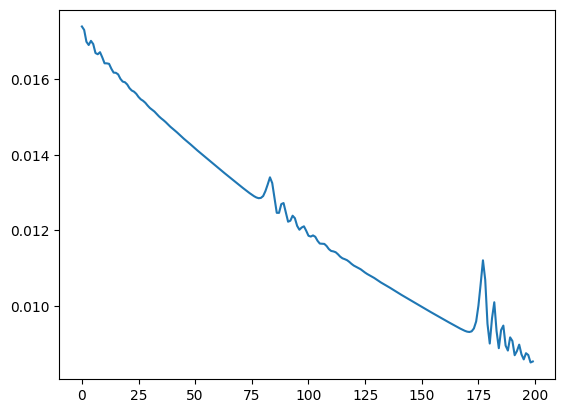

In [94]:
plt.plot(range(epochs),losses)
plt.show()